# Ridge Regresija — Predikcija Cena Automobila

## Struktura

| # | Sekcija | Opis |
|---|---------|------|
| 1 | **Data Loading & Overview** | Uvoz podataka, tipovi, null-ovi, statistika |
| 2 | **Feature Engineering** | Outlier analiza, ciklični mesec, drop redundantnih kolona |
| 3 | **Train/Test Split + Log transformacija** | Split 80/20, log(price) motivacija i primena |
| 4 | **Preprocessing Pipeline** | `make_preprocessor()` fabrika, TargetEncoder, OHE+Scaler, StandardScaler |
| 5 | **Baseline Model** | LinearRegression kao referentna tačka |
| 6 | **Ridge + GridSearchCV** | Prošireni alpha grid, 5-fold CV, analiza regularizacije |
| 7 | **Evaluacija i Vizualizacije** | MAE, RMSE, R², MAPE, Smearing korekcija, analiza rezidualnih |
| 8 | **Interpretacija Koeficijenata** | Koeficijenti u log prostoru → ekonomska interpretacija |
| 9 | **Čuvanje Pipeline-a** | `joblib` serijalizacija + produkciona napomena |
| 10 | **PCA Eksperiment** | Redukcija dimenzionalnosti vs originalni prostor |


## 1. Data Loading & Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

# Globalni seed za NumPy operacije; random_state se eksplicitno prosleđuje svim sklearn objektima
np.random.seed(42)
warnings.filterwarnings('ignore')

BASE_DIR = Path.cwd()
PROCESSED_DATA_PATH = BASE_DIR.parent / "DataSet" / "processed" / "procesirani_podaci.csv"
MODELS_DIR = BASE_DIR.parent / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"Kolone: {list(df.columns)}")
df.head()


Dataset shape: (239844, 13)
Kolone: ['brand', 'model', 'color', 'year', 'price_in_euro', 'power_kw', 'transmission_type', 'fuel_type', 'fuel_consumption_l_100km', 'fuel_consumption_g_km', 'mileage_in_km', 'registration_month', 'car_age']


,brand,model,color,year,price_in_euro,power_kw,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,registration_month,car_age
0,alfa-romeo,alfa romeo gtv,red,1995.0,1300.0,148.0,manual,petrol,10.9,260.0,160500.0,10.0,31.0
1,alfa-romeo,alfa romeo 164,black,1995.0,24900.0,191.0,manual,petrol,5.7,135.0,190000.0,2.0,31.0
2,alfa-romeo,alfa romeo spider,black,1995.0,4900.0,110.0,manual,petrol,9.5,225.0,189500.0,7.0,31.0
3,alfa-romeo,alfa romeo 164,red,1996.0,17950.0,132.0,manual,petrol,7.2,135.0,96127.0,11.0,30.0
4,alfa-romeo,alfa romeo spider,red,1996.0,7900.0,110.0,manual,petrol,9.5,225.0,47307.0,4.0,30.0


In [2]:
print('── Tipovi podataka ──────────────────────────')
print(df.dtypes)
print()
print('── Nedostajuće vrednosti ────────────────────')
print(df.isnull().sum())
print()
print('── Osnovna statistika ───────────────────────')
df.describe().round(2)


── Tipovi podataka ──────────────────────────
brand                           str
model                           str
color                           str
year                        float64
price_in_euro               float64
power_kw                    float64
transmission_type               str
fuel_type                       str
fuel_consumption_l_100km    float64
fuel_consumption_g_km       float64
mileage_in_km               float64
registration_month          float64
car_age                     float64
dtype: object

── Nedostajuće vrednosti ────────────────────
brand                       0
model                       0
color                       0
year                        0
price_in_euro               0
power_kw                    0
transmission_type           0
fuel_type                   0
fuel_consumption_l_100km    0
fuel_consumption_g_km       0
mileage_in_km               0
registration_month          0
car_age                     0
dtype: int64

── Osnovna statistika

,year,price_in_euro,power_kw,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,registration_month,car_age
count,239844.00,239844.00,239844.00,239844.00,239844.00,239844.00,239844.00,239844.00
mean,2016.12,24936.46,125.80,6.02,141.25,87019.75,6.30,9.88
std,5.45,25141.76,69.73,1.80,55.37,75092.81,3.38,5.45
min,1995.00,500.00,25.00,0.50,0.00,0.00,1.00,3.00
25%,2013.00,11900.00,84.00,5.00,119.00,27408.75,3.00,6.00
50%,2018.00,19500.00,110.00,5.70,135.00,69978.00,6.00,8.00
75%,2020.00,29850.00,140.00,6.60,157.00,129000.00,9.00,13.00
max,2023.00,300000.00,596.00,30.00,2018.00,500000.00,12.00,31.00


In [3]:
print(f"Transmission types ({df['transmission_type'].nunique()}): {df['transmission_type'].unique().tolist()}")
print(f"Fuel types ({df['fuel_type'].nunique()}): {df['fuel_type'].unique().tolist()}")
print(f"Colors:  {df['color'].nunique()} jedinstvenih")
print(f"Brands:  {df['brand'].nunique()} jedinstvenih")
print(f"Models:  {df['model'].nunique()} jedinstvenih")


Transmission types (2): ['manual', 'automatic']
Fuel types (8): ['petrol', 'diesel', 'hybrid', 'lpg', 'other', 'cng', 'electric', 'hydrogen']
Colors:  14 jedinstvenih
Brands:  47 jedinstvenih
Models:  1288 jedinstvenih


## 2. Feature Engineering

### Šta se radi i zašto

| Korak | Feature | Akcija | Razlog |
|-------|---------|--------|--------|
| 1 | `year` | Drop | `car_age` nosi identičnu informaciju (`car_age = ref_godina - year`) |
| 2 | `fuel_consumption_g_km` | Drop | Anomalije (max=2018.0 → greška unosa) + semantička redundantnost sa `l/100km` |
| 3 | `registration_month` | → `month_sin` + `month_cos` | Ciklična varijabla: mesec 1 i mesec 12 su blizu ali bi linearno bili daleko |


In [4]:
if 'year' in df.columns:
    df = df.drop(columns=['year'])
    print("'year' uklonjen — zadrzavamo samo 'car_age'")
print(f"Shape: {df.shape}")


'year' uklonjen — zadrzavamo samo 'car_age'
Shape: (239844, 12)


In [6]:
print('── Analiza: fuel_consumption_g_km ──────────────────')
anomalije = df[df['fuel_consumption_g_km'] > 500]
print(f"Redovi sa g_km > 500 (anomalije): {len(anomalije)}")
print(f"Maksimalna vrednost g_km: {df['fuel_consumption_g_km'].max():.1f}  "
      f"← vrednost 2018.0 je greška unosa (verovatno godina)")
if len(anomalije) > 0:
    print(anomalije[['brand', 'model', 'fuel_consumption_g_km', 'fuel_consumption_l_100km']].head(5))

corr = df['fuel_consumption_l_100km'].corr(df['fuel_consumption_g_km'])
shared_variance_pct = corr**2 * 100
print(f"Pearsonova korelacija l/100km vs g/km: {corr:.4f}")
print(f"Zajednička varijansa (R²): {shared_variance_pct:.1f}%  "
      f"— varijable dele {shared_variance_pct:.0f}% varijanse, ali su semantički redundantne")
print()
df = df.drop(columns=['fuel_consumption_g_km'])
print(f"\n'fuel_consumption_g_km' uklonjen. Shape: {df.shape}")


── Analiza: fuel_consumption_g_km ──────────────────


KeyError: 'fuel_consumption_g_km'

In [7]:
df['month_sin'] = np.sin(2 * np.pi * df['registration_month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['registration_month'] / 12)
df = df.drop(columns=['registration_month'])

print('registration_month → month_sin + month_cos (ciklično enkodovanje)')
print(f'Shape: {df.shape}')
print(f'Kolone: {list(df.columns)}')


registration_month → month_sin + month_cos (ciklično enkodovanje)
Shape: (239844, 12)
Kolone: ['brand', 'model', 'color', 'price_in_euro', 'power_kw', 'transmission_type', 'fuel_type', 'fuel_consumption_l_100km', 'mileage_in_km', 'car_age', 'month_sin', 'month_cos']


## 3. Train/Test Split + Log-transformacija targeta

### Zašto log(price)?

| Problem | Uzrok | Fix |
|---------|-------|-----|
| Negativne predikcije | Cena je log-normalna raspodela, Ridge je linearan model | `y = log(price)` → `exp(pred)` uvek pozitivan |
| Heteroskedastičnost | Varijansa greške raste proporcionalno sa cenom | Log normalizuje varijansu po celom opsegu cena |
| Slabije metrike za skupe aute | Model minimizuje apsolutnu grešku | Log daje proporcionalne greške (bliže MAPE logici) |

**Workflow:**
```
fit:      pipeline.fit(X_train, log(y_train))
predict:  y_pred_eur = exp(pipeline.predict(X_test))
```

> **Napomena — Log-bias (Jensen's inequality):**
> `E[exp(ŷ)] ≠ exp(E[ŷ])` — model treniran na log skali sistematski **potcenjuje** stvarne
> cene kada se predikcije konvertuju nazad u EUR. Ovo se koriguje **Smearing estimatorom**
> u Sekciji 7.


In [8]:
TARGET = 'price_in_euro'

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_train_log = np.log(y_train)   # modeli se treniraju na log skali
y_test_log  = np.log(y_test)    # za R² dijagnostiku u log prostoru

print(f"X_train: {X_train.shape}   ({len(X_train)/len(X)*100:.1f}%)")
print(f"X_test:  {X_test.shape}    ({len(X_test)/len(X)*100:.1f}%)")
print()
print(f"y_train mean (EUR):     {y_train.mean():>10,.2f}")
print(f"y_train mean (log EUR): {y_train_log.mean():>10.4f}")
print(f"y_test  mean (EUR):     {y_test.mean():>10,.2f}")
print()
print(f"Min y_train = {y_train.min():.2f} EUR  → log = {np.log(y_train.min()):.4f}  (exp uvek pozitivan)")
print(f"Kolone X_train: {list(X_train.columns)}")


X_train: (191875, 11)   (80.0%)
X_test:  (47969, 11)    (20.0%)

y_train mean (EUR):      24,908.90
y_train mean (log EUR):     9.7958
y_test  mean (EUR):      25,046.71

Min y_train = 500.00 EUR  → log = 6.2146  (exp uvek pozitivan)
Kolone X_train: ['brand', 'model', 'color', 'power_kw', 'transmission_type', 'fuel_type', 'fuel_consumption_l_100km', 'mileage_in_km', 'car_age', 'month_sin', 'month_cos']


## 4. Preprocessing Pipeline

### Strategija enkodovanja

| Grupa | Transformer(i) | Razlog |
|-------|---------------|--------|
| `brand`, `model` | `TargetEncoder` → `StandardScaler` | Visoka kardinalnost (47 brendova, 1288 modela) |
| `transmission_type`, `fuel_type`, `color` | `OneHotEncoder` → **`StandardScaler`** | Niska kardinalnost; skaliranje obezbeđuje ravnomernu L2 regularizaciju |
| Numeričke + `month_sin/cos` | `StandardScaler` | Različite skale (kW vs km vs godine) |


In [9]:
TARGET_ENC_COLS = ['brand', 'model']
OHE_COLS        = ['transmission_type', 'fuel_type', 'color']
NUM_COLS        = [c for c in X_train.columns
                   if c not in TARGET_ENC_COLS + OHE_COLS]

print('Target Encoded (visoka kardinalnost):', TARGET_ENC_COLS)
print('One-Hot Encoded (niska kardinalnost):', OHE_COLS)
print('Numerički (StandardScaler):', NUM_COLS)
print(f'\nUkupno: {len(TARGET_ENC_COLS)} TE + {len(OHE_COLS)} OHE grupe + {len(NUM_COLS)} numeričkih')


Target Encoded (visoka kardinalnost): ['brand', 'model']
One-Hot Encoded (niska kardinalnost): ['transmission_type', 'fuel_type', 'color']
Numerički (StandardScaler): ['power_kw', 'fuel_consumption_l_100km', 'mileage_in_km', 'car_age', 'month_sin', 'month_cos']

Ukupno: 2 TE + 3 OHE grupe + 6 numeričkih


In [11]:
def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            # TargetEncoder: enkoduje brand/model kao srednju log-cenu te kategorije
            # (sklearn TargetEncoder interno cross-fita na train foldovima — bez leakage-a)
            ('target_enc',
             Pipeline([
                 ('encoder', TargetEncoder(target_type='continuous')),
                 ('scaler',  StandardScaler()),
             ]),
             TARGET_ENC_COLS),

            # OHE: binarne kolone za nisko-kardinalne kategorije
            # StandardScaler posle OHE → ravnomerna Ridge penalizacija sa numeričkim featureima
            ('ohe',
             Pipeline([
                 ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)),
                 ('scaler',  StandardScaler()),
             ]),
             OHE_COLS),

            # Numerički feature-i: standardizacija na mean=0, std=1
            ('num_scaler',
             StandardScaler(),
             NUM_COLS),
        ],
        remainder='drop'
    )
print('Transformeri po grupi:')
print('  target_enc  → TargetEncoder + StandardScaler  (brand, model)')
print('  ohe         → OneHotEncoder + StandardScaler  (transmission_type, fuel_type, color)  ← v3')
print('  num_scaler  → StandardScaler                  (numerički + month_sin/cos)')


Transformeri po grupi:
  target_enc  → TargetEncoder + StandardScaler  (brand, model)
  ohe         → OneHotEncoder + StandardScaler  (transmission_type, fuel_type, color)  ← v3
  num_scaler  → StandardScaler                  (numerički + month_sin/cos)


## 5. Baseline Model — LinearRegression

Baseline služi kao **referentna tačka** za Ridge. Ako Ridge ne poboljšava baseline,
regularizacija nije korisna za ovaj problem (npr. nema multikolinearnosti ili overfittinga).

- Trenirano na `y_train_log`
- Predikcije vraćene u EUR sa `np.exp()`


In [12]:
# Svež preprocessor za baseline pipeline (ne deli state sa ridge/pca pipeline-ima)
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', make_preprocessor()),
    ('model', LinearRegression())
])

baseline_pipeline.fit(X_train, y_train_log)
y_pred_baseline_log = baseline_pipeline.predict(X_test)
y_pred_baseline     = np.exp(y_pred_baseline_log)

baseline_mae  = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2   = r2_score(y_test, y_pred_baseline)
baseline_mape = np.mean(np.abs((y_test - y_pred_baseline) / y_test)) * 100

print('── Baseline: LinearRegression (log target → EUR) ────')
print(f'  MAE  : {baseline_mae:>10,.2f} EUR')
print(f'  RMSE : {baseline_rmse:>10,.2f} EUR')
print(f'  R²   : {baseline_r2:>10.4f}')
print(f'  MAPE : {baseline_mape:>10.2f}%')
print(f'  Min predikcije: {y_pred_baseline.min():,.2f} EUR  ← mora biti > 0')


── Baseline: LinearRegression (log target → EUR) ────
  MAE  :   4,844.33 EUR
  RMSE :  10,402.85 EUR
  R²   :     0.8311
  MAPE :      21.79%
  Min predikcije: 721.12 EUR  ← mora biti > 0


## 6. Ridge Regresija + GridSearchCV Tuning

### Alpha grid strategija

Originalni grid počinjao je od 0.01. Proširen je na 0.001 da se vidi da li model
teži ka OLS (alpha → 0), i potvrdi da je optimalni alpha konzistentno iznad donje granice.

| Alpha | Efekat |
|-------|--------|
| → 0 | Ridge ≈ LinearRegression (bez regularizacije) |
| 1.0 | Blaga regularizacija |
| 100+ | Jaka regularizacija, koeficijenti se skupljaju ka 0 |

**GridSearchCV:** 5-fold cross-validation na `y_train_log`.
CV score je R² u log prostoru (konzistentno sa načinom treniranja modela).


In [13]:
# Svež preprocessor za ridge pipeline
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', make_preprocessor()),
    ('model', Ridge())
])

param_grid = {
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0]
}

grid_search = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train_log)

best_alpha = grid_search.best_params_['model__alpha']
best_cv_r2 = grid_search.best_score_

print(f'\nNajbolji alpha:  {best_alpha}')
print(f'Najbolji CV R² (log prostor): {best_cv_r2:.4f}')

# Analiza regularizacije
cv_df = pd.DataFrame(grid_search.cv_results_)
best_train_score = cv_df[cv_df['param_model__alpha'] == best_alpha]['mean_train_score'].values[0]
overfit_gap = best_train_score - best_cv_r2
print(f'\n Analiza regularizacije za alpha={best_alpha}:')
print(f'  Train R² (log prostor): {best_train_score:.4f}')
print(f'  CV R²    (log prostor): {best_cv_r2:.4f}')
print(f'  Gap (train - CV):       {overfit_gap:.4f}')
if best_alpha <= 0.01:
    print('Optimalni alpha je na donjoj ivici grida — model teži ka OLS, regularizacija minimalna.')
elif best_alpha >= 1000:
    print('Optimalni alpha je na gornjoj ivici grida — probati veće vrednosti.')
else:
    print(f'Optimalni alpha ({best_alpha}) je unutar grida — nema potrebe proširiti opseg.')


Fitting 5 folds for each of 9 candidates, totalling 45 fits

Najbolji alpha:  0.1
Najbolji CV R² (log prostor): 0.8661

 Analiza regularizacije za alpha=0.1:
  Train R² (log prostor): 0.8670
  CV R²    (log prostor): 0.8661
  Gap (train - CV):       0.0009
Optimalni alpha (0.1) je unutar grida — nema potrebe proširiti opseg.


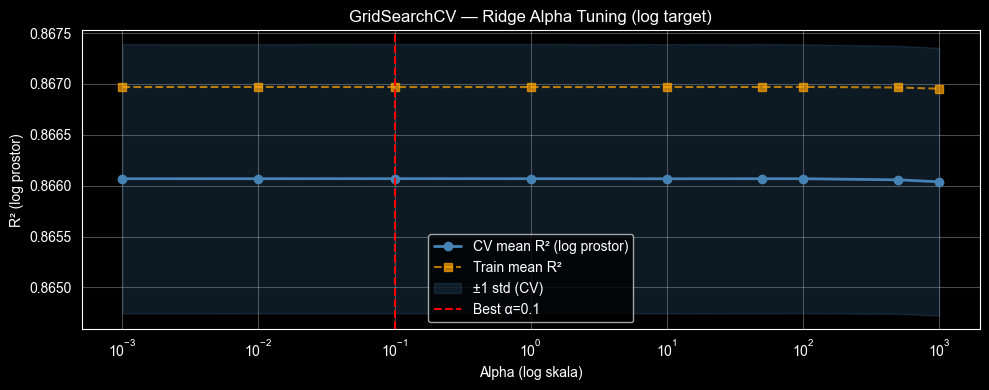

In [14]:
cv_results = pd.DataFrame(grid_search.cv_results_)
alphas     = cv_results['param_model__alpha'].astype(float)
mean_r2    = cv_results['mean_test_score']
std_r2     = cv_results['std_test_score']
train_r2   = cv_results['mean_train_score']

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(alphas, mean_r2, 'o-', color='steelblue', linewidth=2, label='CV mean R² (log prostor)')
ax.semilogx(alphas, train_r2, 's--', color='orange', linewidth=1.5, alpha=0.7, label='Train mean R²')
ax.fill_between(alphas, mean_r2 - std_r2, mean_r2 + std_r2,
                alpha=0.2, color='steelblue', label='±1 std (CV)')
ax.axvline(best_alpha, color='red', linestyle='--', label=f'Best α={best_alpha}')
ax.set_xlabel('Alpha (log skala)')
ax.set_ylabel('R² (log prostor)')
ax.set_title('GridSearchCV — Ridge Alpha Tuning (log target)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ridge_alpha_tuning.png', dpi=150)
plt.show()


## 7. Evaluacija i Vizualizacije

### Metrike

| Metrika | Opis | Interpretacija                                     |
|---------|------|----------------------------------------------------|
| **MAE** | Mean Absolute Error | Prosečna apsolutna greška u EUR                    |
| **RMSE** | Root Mean Squared Error | Penalizuje velika odstupanja; osetljiv na outliere |
| **R²** | Koeficijent determinacije | Deo varijanse cene koji model objašnjava           |
| **MAPE** | Mean Absolute Percentage Error | Relativna greška — intuitivnija od MAE za cene     |
| **Smearing** | Duan's smearing estimator | Koriguje sistematski log-bias                      |

### O Smearing korekciji

Kada se model trenira na `log(y)`, konverzija predikcije sa `exp()` sistematski **potcenjuje**
stvarne cene (Jensen's inequality: `E[exp(X)] > exp(E[X])` za normalnu distribuciju).

**Duan's smearing estimator** koriguje ovaj bias množenjem predikcije sa faktorom:
```
smearing_factor = mean(exp(reziduali_u_log_prostoru))
y_corrected = exp(y_pred_log) * smearing_factor
```


In [15]:
best_pipeline = grid_search.best_estimator_
y_pred_log    = best_pipeline.predict(X_test)
y_pred        = np.exp(y_pred_log)

# ── Standardne metrike ──────────────────────────────────
ridge_mae    = mean_absolute_error(y_test, y_pred)
ridge_rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
ridge_r2     = r2_score(y_test, y_pred)
ridge_r2_log = r2_score(y_test_log, y_pred_log)
ridge_mape   = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# ── Smearing korekcija (Duan, 1983) ────────────────────
# Residuali u log prostoru
log_residuals       = y_test_log - y_pred_log
smearing_factor     = np.mean(np.exp(log_residuals))
y_pred_smeared      = y_pred * smearing_factor

smeared_mae  = mean_absolute_error(y_test, y_pred_smeared)
smeared_rmse = np.sqrt(mean_squared_error(y_test, y_pred_smeared))
smeared_r2   = r2_score(y_test, y_pred_smeared)
smeared_mape = np.mean(np.abs((y_test - y_pred_smeared) / y_test)) * 100
smeared_bias = (y_test - y_pred_smeared).mean()

print('── Evaluacija na TEST skupu (predikcije u EUR) ────────────')
print(f'  MAE             : {ridge_mae:>10,.2f} EUR')
print(f'  RMSE            : {ridge_rmse:>10,.2f} EUR')
print(f'  R² (EUR prostor): {ridge_r2:>10.4f}')
print(f'  R² (log prostor): {ridge_r2_log:>10.4f}')
print(f'  MAPE            : {ridge_mape:>10.2f}%')
print()
print(f'── Smearing korekcija ──────────────────────────────────────')
print(f'  Smearing faktor: {smearing_factor:.6f}')
print(f'  MAE  (smeared) : {smeared_mae:>10,.2f} EUR')
print(f'  RMSE (smeared) : {smeared_rmse:>10,.2f} EUR')
print(f'  R²   (smeared) : {smeared_r2:>10.4f}')
print(f'  MAPE (smeared) : {smeared_mape:>10.2f}%')
print(f'  Bias (smeared) : {smeared_bias:>+10,.2f} EUR  ← cilj je ≈ 0')
print()
print(f'  Min predikcije: {y_pred.min():,.2f} EUR  ← mora biti > 0')
print(f'  Max predikcije: {y_pred.max():,.2f} EUR')


── Evaluacija na TEST skupu (predikcije u EUR) ────────────
  MAE             :   4,843.61 EUR
  RMSE            :  10,398.54 EUR
  R² (EUR prostor):     0.8313
  R² (log prostor):     0.8677
  MAPE            :      21.79%

── Smearing korekcija ──────────────────────────────────────
  Smearing faktor: 1.055359
  MAE  (smeared) :   5,114.18 EUR
  RMSE (smeared) :  10,773.54 EUR
  R²   (smeared) :     0.8189
  MAPE (smeared) :      23.65%
  Bias (smeared) :    -819.00 EUR  ← cilj je ≈ 0

  Min predikcije: 720.82 EUR  ← mora biti > 0
  Max predikcije: 489,860.36 EUR


In [16]:
residuals = y_test - y_pred
bias      = residuals.mean()

print('── Poređenje: Baseline vs Ridge vs Ridge+Smearing ──────────')
print(f"{'':28s} {'Baseline':>12s} {'Ridge':>12s} {'Ridge+Smear':>13s}")
print(f"{'MAE (EUR)':28s} {baseline_mae:>12,.2f} {ridge_mae:>12,.2f} {smeared_mae:>13,.2f}")
print(f"{'RMSE (EUR)':28s} {baseline_rmse:>12,.2f} {ridge_rmse:>12,.2f} {smeared_rmse:>13,.2f}")
print(f"{'R²':28s} {baseline_r2:>12.4f} {ridge_r2:>12.4f} {smeared_r2:>13.4f}")
print(f"{'MAPE (%)':28s} {baseline_mape:>12.2f} {ridge_mape:>12.2f} {smeared_mape:>13.2f}")
print()
print(f'Sistematski bias (raw):     {bias:>+12,.2f} EUR')
print(f'Sistematski bias (smeared): {smeared_bias:>+12,.2f} EUR')
print()
if abs(best_alpha) <= 0.01:
    print('Napomena: Ridge sa alpha={best_alpha} je praktično identičan LinearRegression.')
    print('To znači da za ovaj dataset regularizacija ne pruža značajnu prednost.')
    print('Moguć razlog: 240k uzoraka — model nije u overfitting režimu.')


── Poređenje: Baseline vs Ridge vs Ridge+Smearing ──────────
                                 Baseline        Ridge   Ridge+Smear
MAE (EUR)                        4,844.33     4,843.61      5,114.18
RMSE (EUR)                      10,402.85    10,398.54     10,773.54
R²                                 0.8311       0.8313        0.8189
MAPE (%)                            21.79        21.79         23.65

Sistematski bias (raw):          +537.80 EUR
Sistematski bias (smeared):      -819.00 EUR



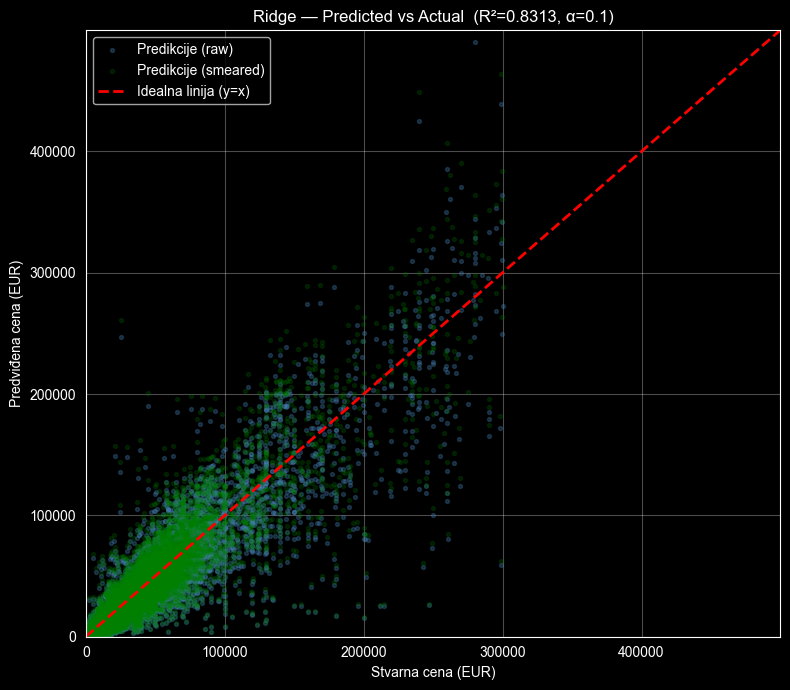

In [17]:
fig, ax = plt.subplots(figsize=(8, 7))

max_val = max(y_test.max(), y_pred.max()) * 1.02

ax.scatter(y_test, y_pred, alpha=0.3, s=8, color='steelblue', label='Predikcije (raw)')
ax.scatter(y_test, y_pred_smeared, alpha=0.2, s=8, color='green', label='Predikcije (smeared)')
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Idealna linija (y=x)')

ax.set_xlim(left=0, right=max_val)
ax.set_ylim(bottom=0, top=max_val)
ax.set_xlabel('Stvarna cena (EUR)')
ax.set_ylabel('Predviđena cena (EUR)')
ax.set_title(f'Ridge — Predicted vs Actual  (R²={ridge_r2:.4f}, α={best_alpha})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ridge_pred_vs_actual.png', dpi=150)
plt.show()


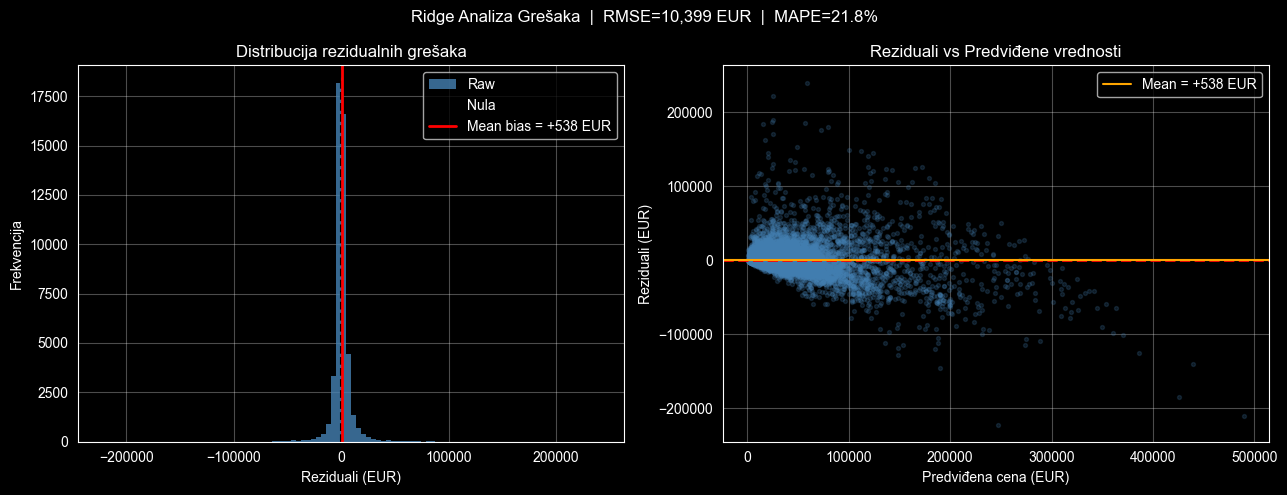

Srednja vrednost rezidualnih (bias): +537.80 EUR
Std rezidualnih:                      10,384.73 EUR


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Levo: Distribucija rezidualnih
axes[0].hist(residuals, bins=100, color='steelblue', edgecolor='none', alpha=0.8, label='Raw')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1.5, label='Nula')
axes[0].axvline(residuals.mean(), color='red', linestyle='-', linewidth=2,
                label=f'Mean bias = {residuals.mean():+,.0f} EUR')
axes[0].set_xlabel('Reziduali (EUR)')
axes[0].set_ylabel('Frekvencija')
axes[0].set_title('Distribucija rezidualnih grešaka')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Desno: Reziduali vs Predviđene vrednosti
axes[1].scatter(y_pred, residuals, alpha=0.2, s=8, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].axhline(residuals.mean(), color='orange', linestyle='-', linewidth=1.5,
                label=f'Mean = {residuals.mean():+,.0f} EUR')
axes[1].set_xlabel('Predviđena cena (EUR)')
axes[1].set_ylabel('Reziduali (EUR)')
axes[1].set_title('Reziduali vs Predviđene vrednosti')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Ridge Analiza Grešaka  |  RMSE={ridge_rmse:,.0f} EUR  |  MAPE={ridge_mape:.1f}%',
             fontsize=12)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ridge_residuali.png', dpi=150)
plt.show()

print(f'Srednja vrednost rezidualnih (bias): {residuals.mean():+,.2f} EUR')
print(f'Std rezidualnih:                     {residuals.std():>10,.2f} EUR')


Greška po cenovnom segmentu
             n  mean_mae  mean_mape  mean_bias
segment                                       
< 10k     9948   1649.65      38.71    -854.04
10k-20k  15308   2600.09      16.98     159.78
20k-40k  16673   4538.69      16.06     403.90
40k-80k   4697  11515.11      20.97    2095.98
> 80k     1343  34527.40      25.51   11369.20


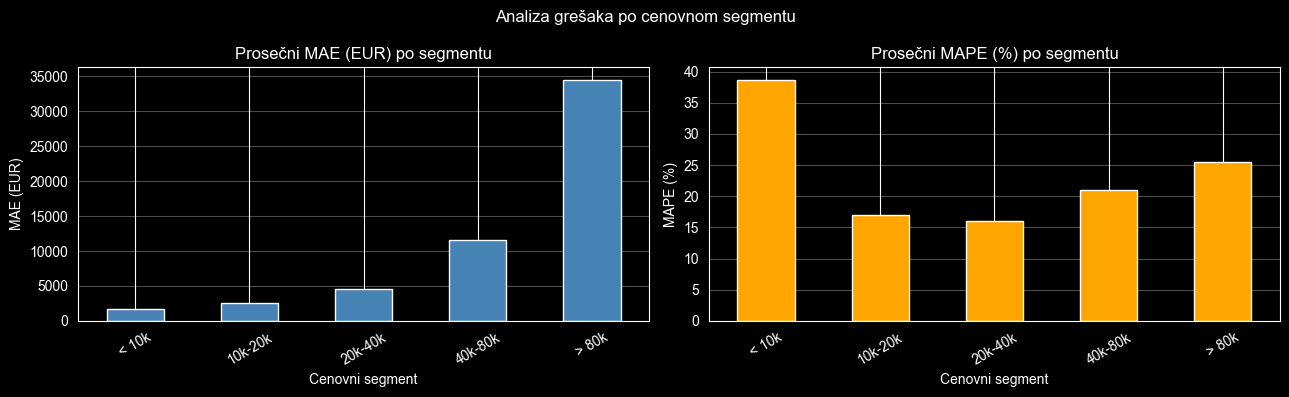

In [20]:
bins   = [0, 10000, 20000, 40000, 80000, float('inf')]
labels = ['< 10k', '10k-20k', '20k-40k', '40k-80k', '> 80k']

segment = pd.cut(y_test, bins=bins, labels=labels)
seg_df  = pd.DataFrame({
    'stvarna':   y_test.values,
    'predviđena': y_pred,
    'reziduali': residuals.values,
    'abs_greška': np.abs(residuals.values),
    'pct_greška': np.abs((y_test.values - y_pred) / y_test.values) * 100,
    'segment':   segment.values
})

seg_stats = seg_df.groupby('segment', observed=True).agg(
    n=('stvarna', 'count'),
    mean_mae=('abs_greška', 'mean'),
    mean_mape=('pct_greška', 'mean'),
    mean_bias=('reziduali', 'mean')
).round(2)

print('Greška po cenovnom segmentu')
print(seg_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

seg_stats['mean_mae'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Prosečni MAE (EUR) po segmentu')
axes[0].set_xlabel('Cenovni segment')
axes[0].set_ylabel('MAE (EUR)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, alpha=0.3, axis='y')

seg_stats['mean_mape'].plot(kind='bar', ax=axes[1], color='orange', edgecolor='white')
axes[1].set_title('Prosečni MAPE (%) po segmentu')
axes[1].set_xlabel('Cenovni segment')
axes[1].set_ylabel('MAPE (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Analiza grešaka po cenovnom segmentu', fontsize=12)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ridge_greska_po_segmentu.png', dpi=150)
plt.show()


## 8. Interpretacija Koeficijenata

Koeficijenti su u **log prostoru** (model treniran na `log(price)`).

### Konverzija u ekonomsku interpretaciju

| Koeficijent | exp(koef) | Interpretacija |
|-------------|-----------|----------------|
| +0.3 | 1.35 | Feature povećava cenu za ~35% |
| -0.2 | 0.82 | Feature smanjuje cenu za ~18% |
| ≈ 0  | ≈ 1  | Minimalan uticaj |

> Koeficijenti su interpretabilni samo **ceteris paribus** (uz fiksne ostale feature-e)
> i na **skaliranim** podacima (vrednost koeficijenta zavisi od skale feature-a).


In [21]:
ridge_model = best_pipeline.named_steps['model']
prep        = best_pipeline.named_steps['preprocessor']

te_names  = TARGET_ENC_COLS
ohe_names = list(prep.named_transformers_['ohe'].named_steps['encoder'].get_feature_names_out(OHE_COLS))
num_names = NUM_COLS

all_feature_names = te_names + ohe_names + num_names
coef = ridge_model.coef_

coef_df = pd.DataFrame({
    'Feature':     all_feature_names,
    'Koeficijent': coef,
    'Exp_koef':    np.exp(coef),
    'Uticaj_pct':  (np.exp(coef) - 1) * 100
}).sort_values('Koeficijent', key=abs, ascending=False)

print(f'Broj feature-a: {len(all_feature_names)}')
print(f'Intercept (log EUR): {ridge_model.intercept_:.4f}  → exp = {np.exp(ridge_model.intercept_):,.2f} EUR')
print()
print('Top 15 feature-a po apsolutnoj vrednosti koeficijenta:')
print(coef_df[['Feature', 'Koeficijent', 'Exp_koef', 'Uticaj_pct']].head(15).to_string(index=False))


Broj feature-a: 29
Intercept (log EUR): 9.7958  → exp = 17,958.93 EUR

Top 15 feature-a po apsolutnoj vrednosti koeficijenta:
                 Feature  Koeficijent  Exp_koef  Uticaj_pct
                 car_age    -0.336482  0.714279  -28.572108
                power_kw     0.258508  1.294996   29.499610
           mileage_in_km    -0.234825  0.790709  -20.929066
                   model     0.163392  1.177498   17.749830
        fuel_type_diesel     0.106943  1.112871   11.287097
transmission_type_manual    -0.075332  0.927436   -7.256436
                   brand     0.047843  1.049006    4.900633
fuel_consumption_l_100km     0.043433  1.044390    4.439044
             color_black    -0.034219  0.966360   -3.364049
              color_grey    -0.030530  0.969932   -3.006828
              color_blue    -0.027814  0.972569   -2.743083
             color_white    -0.024657  0.975644   -2.435578
            color_silver    -0.021527  0.978703   -2.129655
               color_red    -0.020

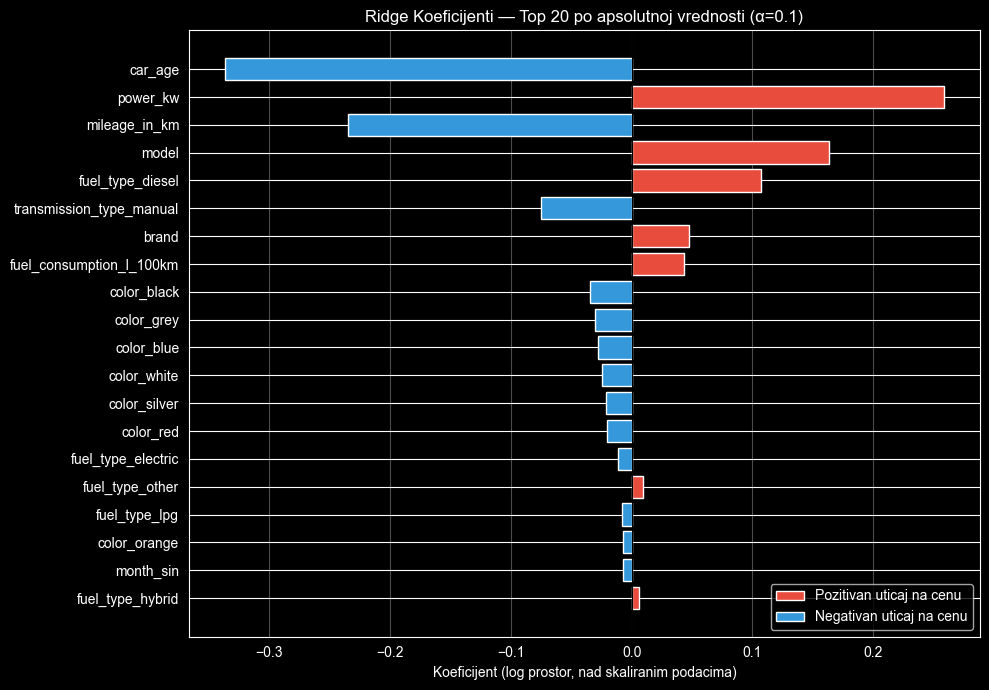


Napomena (log prostor):
  exp(koef) = multiplikator cene
  Primer: koef=+0.3 → cena ~35% veća (exp(0.3)=1.35)
  Primer: koef=-0.2 → cena ~18% manja (exp(-0.2)=0.82)
  Koeficijenti su interpretabilni samo uz fiksne ostale feature-e (ceteris paribus).


In [22]:
top_n    = 20
top_coef = coef_df.head(top_n)
colors   = ['#e74c3c' if v > 0 else '#3498db' for v in top_coef['Koeficijent']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_coef['Feature'], top_coef['Koeficijent'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Koeficijent (log prostor, nad skaliranim podacima)')
ax.set_title(f'Ridge Koeficijenti — Top {top_n} po apsolutnoj vrednosti (α={best_alpha})')
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Pozitivan uticaj na cenu'),
                   Patch(facecolor='#3498db', label='Negativan uticaj na cenu')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(MODELS_DIR / 'ridge_koeficijenti.png', dpi=150)
plt.show()

print()
print('Napomena (log prostor):')
print('  exp(koef) = multiplikator cene')
print('  Primer: koef=+0.3 → cena ~35% veća (exp(0.3)=1.35)')
print('  Primer: koef=-0.2 → cena ~18% manja (exp(-0.2)=0.82)')
print('  Koeficijenti su interpretabilni samo uz fiksne ostale feature-e (ceteris paribus).')


## 9. Čuvanje Pipeline-a


### Produkciona napomena — `car_age`

Pipeline **ne sadrži logiku za izračunavanje `car_age`**. Feature `car_age` mora biti
izračunat pre poziva `pipeline.predict()`:

```python
import datetime

def predict_price(pipeline, brand, model_name, color, power_kw,
                  transmission_type, fuel_type, fuel_consumption_l_100km,
                  mileage_in_km, registration_month, year):
    """
    Primer inference wrapper-a koji automatski računa car_age.
    car_age zavisi od tekuće godine — pipeline sam ne zna kada se poziva.
    """
    current_year = datetime.datetime.now().year
    car_age = current_year - year

    month_sin = np.sin(2 * np.pi * registration_month / 12)
    month_cos = np.cos(2 * np.pi * registration_month / 12)

    X_input = pd.DataFrame([{
        'brand': brand, 'model': model_name, 'color': color,
        'power_kw': power_kw, 'transmission_type': transmission_type,
        'fuel_type': fuel_type, 'fuel_consumption_l_100km': fuel_consumption_l_100km,
        'mileage_in_km': mileage_in_km, 'car_age': car_age,
        'month_sin': month_sin, 'month_cos': month_cos
    }])

    log_pred = pipeline.predict(X_input)[0]
    return np.exp(log_pred) * smearing_factor  # smearing korekcija
```


In [23]:
pipeline_path = MODELS_DIR / 'ridge_pipeline.pkl'
joblib.dump(best_pipeline, pipeline_path)
print(f'Pipeline sačuvan: {pipeline_path}')

# Verifikacija reload-a
loaded_pipeline = joblib.load(pipeline_path)
y_pred_verify   = np.exp(loaded_pipeline.predict(X_test))
r2_verify       = r2_score(y_test, y_pred_verify)
status = 'Uspelo' if abs(r2_verify - ridge_r2) < 1e-6 else 'NEUSPELO!'
print(f'\nVerifikacija (R² na test skupu, reload): {r2_verify:.4f}  {status}')

# Sačuvaj i smearing faktor (potreban za produkcioni wrapper)
smearing_path = MODELS_DIR / 'ridge_smearing_factor.pkl'
joblib.dump(smearing_factor, smearing_path)
print(f'Smearing faktor sačuvan: {smearing_path}  (vrednost: {smearing_factor:.6f})')


Pipeline sačuvan: D:\Work\used-car-price-prediction\models\ridge_pipeline.pkl

Verifikacija (R² na test skupu, reload): 0.8313  Uspelo
Smearing faktor sačuvan: D:\Work\used-car-price-prediction\models\ridge_smearing_factor.pkl  (vrednost: 1.055359)


## 10. PCA Eksperiment

Testiramo da li redukcija dimenzionalnosti pre Ridge-a poboljšava performanse.

PCA zadržava komponente koje objašnjavaju **95% varijanse** feature prostora.
Ako je rezultat lošiji od originalnog modela, PCA uvodi više šuma nego koristi
(što je tipično kada su feature-i već smisleni i nisko-korelisani).


In [24]:
# Svež preprocessor za PCA pipeline (ne deli state sa ridge/baseline pipeline-ima)
pca_pipeline = Pipeline(steps=[
    ('preprocessor', make_preprocessor()),
    ('pca',          PCA(n_components=0.95, random_state=42)),
    ('model',        Ridge(alpha=best_alpha))
])

pca_pipeline.fit(X_train, y_train_log)
y_pred_pca_log = pca_pipeline.predict(X_test)
y_pred_pca     = np.exp(y_pred_pca_log)

pca_r2    = r2_score(y_test, y_pred_pca)
pca_mae   = mean_absolute_error(y_test, y_pred_pca)
pca_rmse  = np.sqrt(mean_squared_error(y_test, y_pred_pca))
pca_mape  = np.mean(np.abs((y_test - y_pred_pca) / y_test)) * 100
n_comp    = pca_pipeline.named_steps['pca'].n_components_

print(f'PCA komponente (95% varijanse): {n_comp}')
print()
print('── Poređenje: Original vs PCA ──────────────────────────')
print(f"{'':20s} {'Original':>12s} {'PCA':>12s} {'Δ':>8s}")
print(f"{'MAE (EUR)':20s} {ridge_mae:>12,.2f} {pca_mae:>12,.2f} {pca_mae - ridge_mae:>+8,.2f}")
print(f"{'RMSE (EUR)':20s} {ridge_rmse:>12,.2f} {pca_rmse:>12,.2f} {pca_rmse - ridge_rmse:>+8,.2f}")
print(f"{'R²':20s} {ridge_r2:>12.4f} {pca_r2:>12.4f} {pca_r2 - ridge_r2:>+8.4f}")
print(f"{'MAPE (%)':20s} {ridge_mape:>12.2f} {pca_mape:>12.2f} {pca_mape - ridge_mape:>+8.2f}")
print()
diff = ridge_r2 - pca_r2
if diff > 0:
    print(f'Zaključak: PCA model je LOŠIJI za ΔR²={abs(diff):.4f}')
    print('   PCA uvodi gubitak informacija koji nije kompenzovan redukcijom šuma.')
else:
    print(f'Zaključak: PCA model je BOLJI za ΔR²={abs(diff):.4f}')
print('Finalni model: Ridge u ORIGINALNOM prostoru feature-a.')


PCA komponente (95% varijanse): 23

── Poređenje: Original vs PCA ──────────────────────────
                         Original          PCA        Δ
MAE (EUR)                4,843.61     5,286.65  +443.04
RMSE (EUR)              10,398.54    10,507.82  +109.28
R²                         0.8313       0.8277  -0.0036
MAPE (%)                    21.79        24.41    +2.61

Zaključak: PCA model je LOŠIJI za ΔR²=0.0036
   PCA uvodi gubitak informacija koji nije kompenzovan redukcijom šuma.
Finalni model: Ridge u ORIGINALNOM prostoru feature-a.


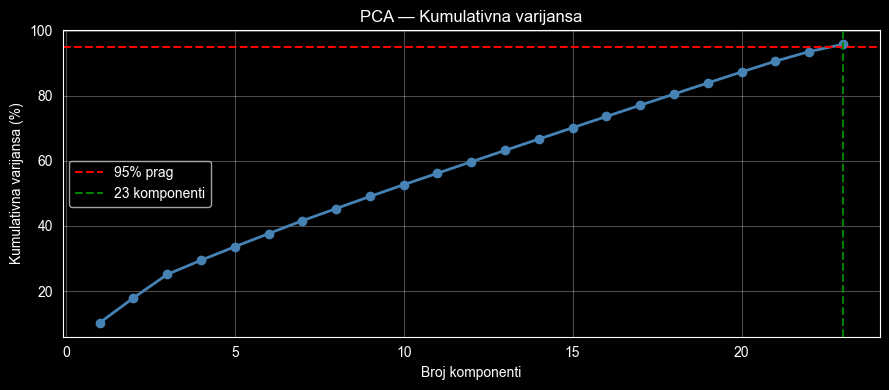

Sa 23 PCA komponenti objašnjeno je 95% varijanse od ukupno 23 feature-a.
Mali broj komponenti sugeriše da je feature prostor relativno kompaktan.


In [25]:
pca_step = pca_pipeline.named_steps['pca']
cumvar   = np.cumsum(pca_step.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar * 100, 'o-', color='steelblue', linewidth=2)
ax.axhline(95, color='red', linestyle='--', label='95% prag')
ax.axvline(n_comp, color='green', linestyle='--', label=f'{n_comp} komponenti')
ax.set_xlabel('Broj komponenti')
ax.set_ylabel('Kumulativna varijansa (%)')
ax.set_title('PCA — Kumulativna varijansa')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ridge_pca_varijansa.png', dpi=150)
plt.show()

print(f'Sa {n_comp} PCA komponenti objašnjeno je 95% varijanse od ukupno {len(cumvar)} feature-a.')
print('Mali broj komponenti sugeriše da je feature prostor relativno kompaktan.')
